# Store spectral thickness coefficients

---

This notebook utilizes the eigenmode basis (computed in 04_1) to map the spectral coefficients of high-resolution cortical thickness phenotypes for all individual scans passing inclusion criteria (excluding individuals with medical diagnosis, low quality surface reconstructions, as well as excluding repeat scans of the same individual).

These spectral coefficients will be used in later notebooks (e.g. 05_01) to fit SNM.

**Note:** This notebook should be executed after 04_01

### package imports and basic functions

---

In [1]:
import os
import gc
import sys
import glob
import json
import random
import datetime
import importlib
import itertools
import numpy as np
from scipy import spatial
import scipy.sparse as sparse
import scipy.stats as stats
import pandas as pd
import nibabel as nib
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from tqdm.auto import tqdm
import joblib


In [2]:
%load_ext autoreload
%autoreload 2

# Path to add to src folder (to use local version of spectranorm)
sys.path.append(os.path.abspath("/mountpoint/code/projects/spectranorm/package/spectranorm/src/"))

from spectranorm import snm


In [3]:
class MyNumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        else:
            return super(MyEncoder, self).default(obj)


def ensure_dir(file_name):
    os.makedirs(os.path.dirname(file_name), exist_ok=True)
    return file_name


def list_dirs(path=os.getcwd()):
    files = glob.glob(os.path.join(path, '*'))
    files = [x for x in files if os.path.isdir(x)]
    return files


def file_exists(file_name, path_name=os.getcwd()):
    return os.path.isfile(os.path.join(path_name, file_name))


def write_json(json_obj, file_path):
    with open(file_path, 'w') as outfile:
        json.dump(json_obj, outfile, sort_keys=True, indent=4,
                  cls=MyNumpyEncoder)
    return json_obj


def load_json(file_path):
    with open(file_path, 'r') as infile:
        return json.load(infile)


def write_np(np_obj, file_path):
    with open(file_path, 'wb') as outfile:
        np.save(outfile, np_obj)


def load_np(file_path):
    with open(file_path, 'rb') as infile:
        return np.load(infile)


In [4]:
# use tex for plotting
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']


## Load aggregated data

---

In [5]:
demography_df = pd.read_parquet(f'/mountpoint/data/normative/datasets/all_datasets/demography.parquet').reset_index(drop=True)


## Load eigenmodes

---

In [6]:
%%time
# desired number of modes
n_modes = 10_000

# load the stored eigenmodes
eigenmode_basis = snm.utils.gsp.EigenmodeBasis.load(
    "/mountpoint/code/projects/normative_brain_charts/data/rw_cortical_connectome_eigenmode_basis_cifti.joblib"
).reduce(n_modes=n_modes)


CPU times: user 727 μs, sys: 473 μs, total: 1.2 ms
Wall time: 952 μs


In [7]:
eigenmode_basis.n_modes

10000

## Spectral coefficients of thickness

---

In [8]:
demography_df['dataset'].unique()

array(['ABCD', 'ABIDE', 'ADHD200', 'ADNI', 'AIBL', 'AOMIC', 'ASRB',
       'BGSP', 'BHRC', 'CCNP', 'CORR', 'DLBS', 'GUSTO', 'HBN', 'HCP-A',
       'HCP-D', 'HCP-YA', 'IXI', 'NKI', 'OASIS', 'PNC', 'SALD', 'SG70',
       'SG_Lifespan', 'SINGER', 'SLIM', 'SPRESTO', 'TCP', 'UKB', 'WAYNE'],
      dtype=object)

In [17]:
import os
import numpy as np

def compute_spectral_coeffs(data_paths, output_path=None, eigenmode_basis=eigenmode_basis):
    coeffs = np.nan * np.zeros(
        (len(data_paths), eigenmode_basis.n_modes),
        dtype=eigenmode_basis.eigenvectors.dtype,
    )
    for i, data_path in enumerate(data_paths):
        coeffs[i, :] = np.load(data_path) @ eigenmode_basis.eigenvectors

    if output_path is not None:
        np.save(output_path, coeffs)

    return coeffs

spectral_coefficients = {}

for dataset in tqdm(demography_df['dataset'].unique(), desc="Datasets: "):
    file_name = f"/mountpoint/data/normative/spectral_coefficients/{dataset}.thickness.fslr.10000.npy"

    # Expected number of subjects for this dataset
    n_subjects = (demography_df['dataset'] == dataset).sum()

    needs_recompute = False

    if os.path.exists(file_name):
        arr = np.load(file_name)
        if arr.shape[0] != n_subjects:
            print(f"⚠️ Shape mismatch for {file_name}: {arr.shape[0]} vs {n_subjects}. Deleting and recomputing.")
            os.remove(file_name)
            needs_recompute = True
        else:
            spectral_coefficients[dataset] = arr
    else:
        needs_recompute = True

    if needs_recompute:
        file_list = []
        for idx, row in tqdm(
            demography_df[demography_df['dataset'] == dataset].iterrows(),
            desc=f"Listing {dataset} Subjects: ", leave=False
        ):
            file_list.append(
                f"/mountpoint/data/normative/fs_LR_32k/{dataset}/{(row.subject_index%100):02d}/{row.subject_folder}.thickness.fslr.npy"
            )
        spectral_coefficients[dataset] = compute_spectral_coeffs(
            data_paths=tqdm(file_list, desc=f"Computing Spectral Coefficients for {dataset} Subjects: ", leave=False),
            output_path=ensure_dir(file_name),
        )


Datasets:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
%%time
np.save(
    ensure_dir(f"/mountpoint/data/normative/spectral_coefficients/all_datasets.thickness.fslr.10000.npy"),
    np.concatenate([spectral_coefficients[dataset] for dataset in demography_df['dataset'].unique()]),
)

---

Now that we have stored the spectral coefficients of thickness, let's make a visualization to ensure it worked as expected. By definition, the first spectral coefficient should capture mean thickness of each individual. We will visually assess this below:

CPU times: user 0 ns, sys: 319 ms, total: 319 ms
Wall time: 374 ms


Text(0.5, 1.0, 'Mean thickness changes by age')

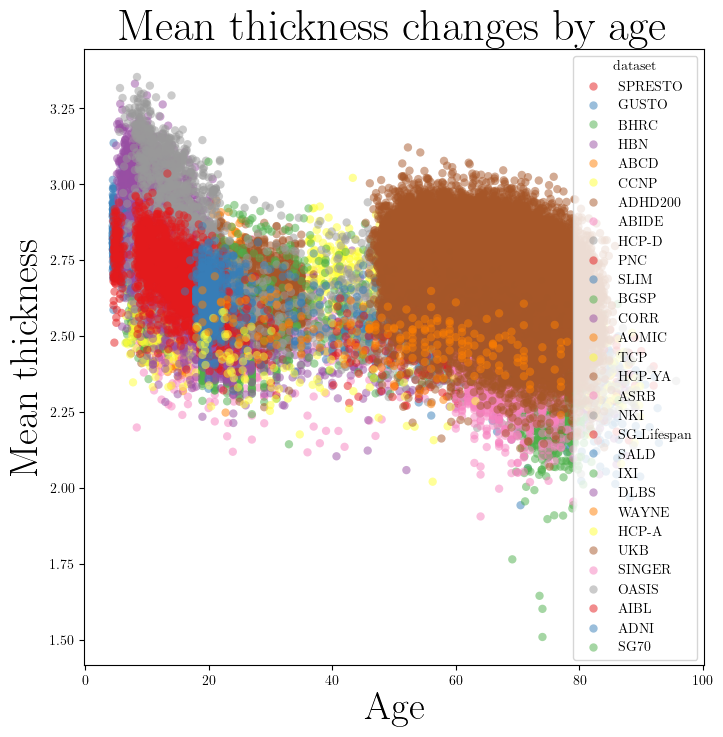

In [13]:
%%time

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

data_order = demography_df.groupby(by=["dataset"])["age"].median().sort_values().index

sns.scatterplot(
    data=demography_df,
    x='age',
    y='thickness',
    ax=ax,
    linewidth=0,
    hue='dataset',
    palette="Set1",
    alpha = 0.5,
    hue_order=data_order,
)

# ax.set_xlim(20,40)
# ax.set_ylim(2.2,3)

ax.set_xlabel('Age', fontsize=28)
ax.set_ylabel('Mean thickness', fontsize=28)

ax.set_title('Mean thickness changes by age', fontsize=32)


In [14]:
demography_df["mm1"] = np.concatenate([spectral_coefficients[dataset][:,0] for dataset in demography_df['dataset'].unique()])

CPU times: user 20.2 ms, sys: 210 ms, total: 230 ms
Wall time: 177 ms


Text(0.5, 1.0, 'Mean thickness changes by age')

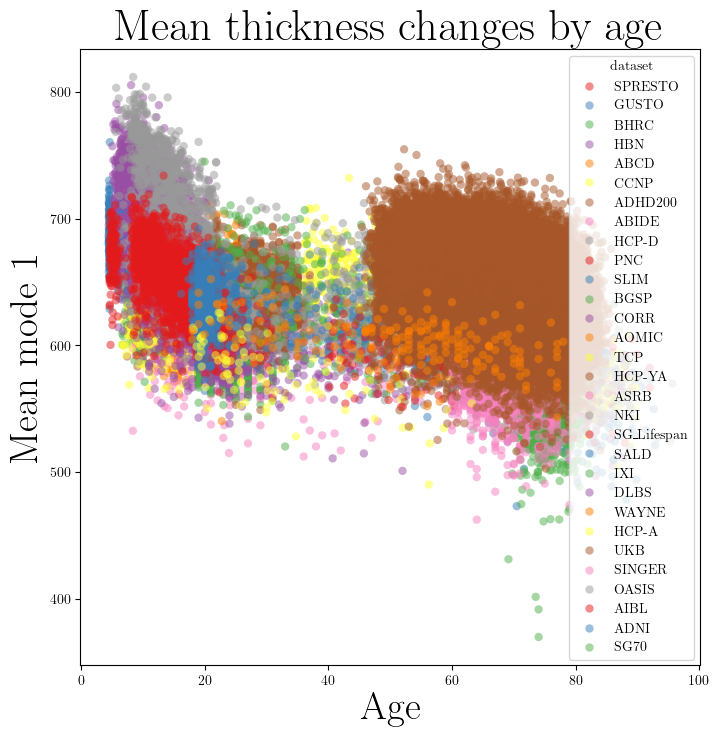

In [15]:
%%time

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

data_order = demography_df.groupby(by=["dataset"])["age"].median().sort_values().index

sns.scatterplot(
    data=demography_df,
    x='age',
    y='mm1',
    ax=ax,
    linewidth=0,
    hue='dataset',
    palette="Set1",
    alpha = 0.5,
    hue_order=data_order,
)

# ax.set_xlim(20,40)
# ax.set_ylim(2.2,3)

ax.set_xlabel('Age', fontsize=28)
ax.set_ylabel('Mean mode 1', fontsize=28)

ax.set_title('Mean thickness changes by age', fontsize=32)


In [16]:
np.concatenate([spectral_coefficients[dataset] for dataset in demography_df['dataset'].unique()]).shape

(78405, 10000)